# Falcon Preimage Attack

## load file

In [1]:
import h5py
from matplotlib import pyplot as plt
import numpy as np
from tqdm import tqdm
import json

In [2]:
nb_tests = 1
nb_traces = 100000
input_file = "traces_cw.hdf5"
file = h5py.File(input_file, "r")
test_sets = [elem for elem in file]

assert nb_tests <= len(test_sets)
assert nb_traces <= min([len(file[elem]) for elem in test_sets])

In [3]:
challenges = []
traces = []

key_group = file[test_sets[0]]
key = list(key_group.attrs["key"])
LOGN = key_group.attrs["logn"]
DIM = 1 << LOGN
HALF = DIM >> 1
print("LOGN: ", LOGN)
print("key (h): ", key)

LOGN:  4
key (h):  [-1, 1, -1, -1, 1, -3, -11, 9, -2, 2, -8, -4, 2, 0, 1, -2]


> [!NOTE]  
> This may take a while.

In [4]:
datasets = [elem for elem in key_group]
for elem in datasets[:nb_traces]:
    dataset = key_group[elem][:,]
    traces.append(dataset)
    challenges.append(key_group[elem].attrs["challenge"])
    # plt.plot(dataset)
    # print(challenges)

del datasets

In [5]:
from fft import FFT

key_fft = key[:]
FFT(key_fft, LOGN)

print(key)
print(key_fft)

[-1, 1, -1, -1, 1, -3, -11, 9, -2, 2, -8, -4, 2, 0, 1, -2]
[-0.6708274272647445, -8.735004859344038, 6.181888732383378, -3.604483570520786, 6.3637086359788455, -10.962038539213115, 3.893656266606911, -0.466899238626453, -13.214700530872818, -21.650081017436797, 11.49073061985878, 23.859332302689403, 15.099874463096626, -8.8005447203425, -23.44045906136008, 0.6558479443673804]


## find indices

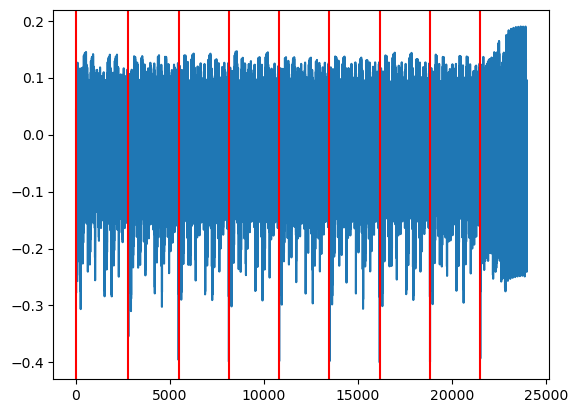

In [6]:
sub_trace_array = traces[:20]

trace_avg = sub_trace_array[0]
for i in range(1, len(sub_trace_array)):
    trace_avg += sub_trace_array[i]
trace_avg /= len(sub_trace_array)

def find_round_indexes(trace):
    start = 0
    end = 18900
    num_rounds = 9
    window = 200

    d = (end - start) / (num_rounds - 2)

    round_indexes = [int(start + i * d) for i in range(num_rounds)]

    for i in range(num_rounds):
        center = round_indexes[i]
        left = max(0, center - window)
        right = min(len(trace), center + window)
        local_min = np.argmin(trace[left:right])
        round_indexes[i] = left + local_min

    return round_indexes

round_indexes =  find_round_indexes(sub_trace_array[1])

plt.figure(0)
plt.plot(trace_avg)
for i in round_indexes:
    plt.axvline(x=i, color='r')
plt.show()

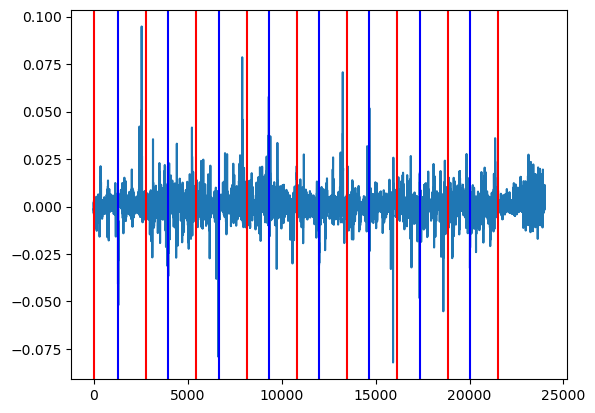

In [7]:
def find_middles(trace, round_indexes):
    num_rounds = 8
    window = 200
    
    middles = [(round_indexes[i]+round_indexes[i+1])/2 for i in range(num_rounds)]
    for i in range(num_rounds):
        center = int(middles[i])
        left = max(0, center - window)
        right = min(len(trace), center + window)
        local_max = np.argmax(abs(trace[left:right]))
        middles[i] = left + local_max  # 加回 offset

    return middles

middles = find_middles(sub_trace_array[1]-trace_avg, round_indexes)

plt.figure(1)
plt.plot(sub_trace_array[1]-trace_avg)
    
for i in round_indexes:
    plt.axvline(x=i, color='r')
    
for i in middles:
    plt.axvline(x=i, color='b')
plt.show()

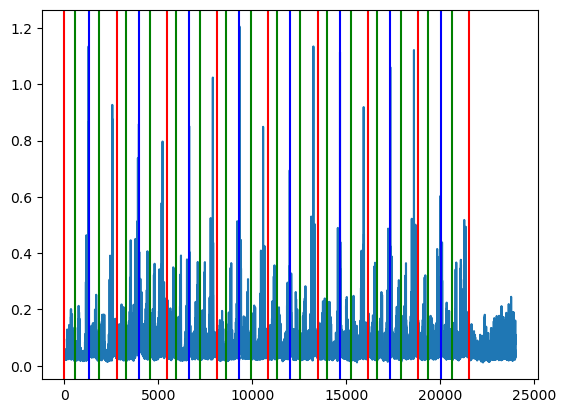

In [8]:
def find_splits(trace, round_indexes, middles):
    num_rounds = 8
    window = 110
    
    splits_left = [(round_indexes[i]+middles[i])/2 for i in range(num_rounds)]
    splits_right = [(round_indexes[i+1]+middles[i])/2 for i in range(num_rounds)]
    
    for i in range(num_rounds):
        center = int(splits_left[i])
        left = center-300
        local_min = 1e10
        local_min_idx = center
        for j in range(left, center):
        
            integral = sum(trace[j-window:j+window])
            if integral < local_min:
                local_min = integral
                local_min_idx = j
                
        splits_left[i] = local_min_idx 
        
    for i in range(num_rounds):
        center = int(splits_right[i])
        left = center-300
        local_min = 1e10
        local_min_idx = center
        for j in range(left, center):
        
            integral = sum(trace[j-window:j+window])
            if integral < local_min:
                local_min = integral
                local_min_idx = j
                
        splits_right[i] = local_min_idx  

    return splits_left + splits_right

splits = find_splits(sum(abs(sub_trace_array-trace_avg)), round_indexes, middles)

plt.figure(3)

# for t in sub_trace_array:
#     plt.plot(t-trace_avg)
plt.plot(sum(abs(sub_trace_array-trace_avg)))

for i in round_indexes:
    plt.axvline(x=i, color='r')
    
for i in middles:
    plt.axvline(x=i, color='b')
    
for i in splits:
    plt.axvline(x=i, color='g')
plt.show()

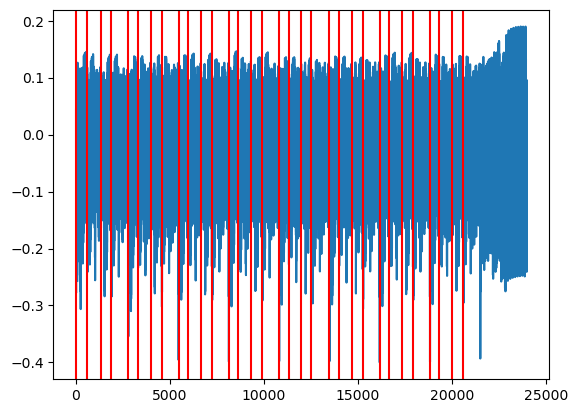

[5, 2785, 5461, 8137, 10813, 13489, 16165, 18841, 1305, 3965, 6641, 9317, 11989, 14669, 17345, 20021, 574, 3276, 5959, 8595, 11310, 13987, 16655, 19339, 1839, 4553, 7231, 9907, 12531, 15255, 17935, 20611]


In [9]:
indexes = round_indexes[:8]
indexes += middles
indexes += splits

plt.figure(4)
plt.plot(trace_avg)
for i in indexes:
    plt.axvline(x=i, color='r')
plt.show()
print(indexes)

## perform attack

In [10]:
PRECISION = 8
TARGET_TERM = 2

In [11]:
def decompose(x: np.float64):
    n = np.abs(x).view(np.int64)
    negative = (x < 0) * 1
    exponent = (n >> 52) & 0x7FF
    significand = (n & np.int64((1 << 52) - 1)) | np.int64(1 << 52)
    return (negative, exponent, significand)

def get_float(s, e, zu):
    return (-1) ** s * 2.0 ** (e - 1023 - 52) * zu

def guess_2_mantissa(guess):
    return guess << (52 - PRECISION)

In [12]:
def perform_cpa(keys, traces, challenges, dist):

    numtraces = len(traces)
    numpoint = np.shape(traces)[1]
    cpaoutput = {}
    maxcpa = {}
    correlations = {i: [] for i in keys}

    for kguess in tqdm(keys, desc="Key guess loop"):
        sumnum = np.zeros(numpoint)
        sumden1 = np.zeros(numpoint)
        sumden2 = np.zeros(numpoint)

        hyp = np.zeros(numtraces)
        for tnum in range(0, numtraces):
            hyp[tnum] = dist(challenges[tnum], kguess)

        meanh = np.mean(hyp, dtype=np.float64)
        meant = np.mean(traces, axis=0, dtype=np.float64)

        for tnum in range(0, numtraces):
            hdiff = hyp[tnum] - meanh
            tdiff = traces[tnum, :] - meant

            sumnum = sumnum + (hdiff * tdiff)
            sumden1 = sumden1 + hdiff * hdiff
            sumden2 = sumden2 + tdiff * tdiff


            den = np.sqrt(sumden1 * sumden2)
            with np.errstate(divide='ignore', invalid='ignore'):
                cpaoutput_tmp = np.where(den != 0, sumnum / den, 1.0)
            maxcpa_tmp = max(abs(cpaoutput_tmp))

            correlations[kguess].append(maxcpa_tmp)

        den = np.sqrt(sumden1 * sumden2)
        with np.errstate(divide='ignore', invalid='ignore'):
            cpaoutput[kguess] = np.where(den != 0, sumnum / den, 1.0)
        maxcpa[kguess] = max(abs(cpaoutput[kguess]))

    guess = max(maxcpa, key=lambda y: abs(maxcpa[y]))
    return guess, correlations

In [13]:
HW = [bin(n).count("1") for n in range(0, 2048)]

def CxB_dist(op, key):
    s, e, m = decompose(op)
    B = m & 0x1FFFFFF
    CxB = key * B
    return HW[CxB >> 25]

def CxA_dist(op, key):
    s, e, m = decompose(op)
    B = m & 0x1FFFFFF
    CxB = key * B
    return HW[CxB >> 25]

def CxB_CxA_dist(op, key):
    s, e, m = decompose(op)
    A = m << 25
    B = m & 0x1FFFFFF
    CxA = (key * A) << 25
    CxB = key * B
    CxB_CxA = CxB + CxA
    return HW[((CxB_CxA) & 0xFFFFFFFFFFF) >> 33]

In [14]:
def recover_mantissa(traces, challenges, dist):

    start = 0  # POI: change if needed
    end = -1  # POI: change if needed
    traces = np.array([t[start:end] for t in traces], dtype=np.float64)

    mantissas = [i for i in range(1 << PRECISION)]
    keys = [1 << PRECISION | m for m in mantissas]

    guess, correlations = perform_cpa(keys, traces, challenges, dist)
    guess = [get_float(0, 1024 + i, guess_2_mantissa(guess)) for i in range(-12, 8)]

    return guess, correlations

partial_traces = np.array(
    [t[indexes[4*TARGET_TERM] : indexes[4*TARGET_TERM+1]] for t in traces]
)
partial_challenges = np.array([row[TARGET_TERM] for row in challenges])

recovered_CxA, correlations_CxA = recover_mantissa(partial_traces, partial_challenges, CxA_dist)
recovered_CxB, correlations_CxB = recover_mantissa(partial_traces, partial_challenges, CxB_dist)
recovered_CxB_CxA, correlations_CxB_CxA = recover_mantissa(partial_traces, partial_challenges, CxB_CxA_dist)

Key guess loop:   0%|          | 0/256 [00:00<?, ?it/s]C:\Users\davidking\AppData\Local\Temp\ipykernel_3604\1069709471.py:19: RuntimeWarning: overflow encountered in scalar multiply
  CxA = (key * A) << 25
Key guess loop: 100%|██████████| 256/256 [1:05:03<00:00, 15.25s/it]


In [15]:
with open("correlations/correlations_CxB.json", "w", encoding="utf-8") as f:
    json.dump(correlations_CxB, f, ensure_ascii=False, indent=2)

with open("correlations/correlations_CxA.json", "w", encoding="utf-8") as f:
    json.dump(correlations_CxA, f, ensure_ascii=False, indent=2)

with open("correlations/correlations_CxB_CxA.json", "w", encoding="utf-8") as f:
    json.dump(correlations_CxB_CxA, f, ensure_ascii=False, indent=2)

## plot correlation

> [!NOTE]  
> You can skip this if skipping former steps.

In [16]:
def load_correlation_data():
    with open("./correlations/correlations_CxB.json", "r") as f:
        correlations_CxB = json.load(f)
    with open("./correlations/correlations_CxA.json", "r") as f:
        correlations_CxA = json.load(f)
    with open("./correlations/correlations_CxB_CxA.json", "r") as f:
        correlations_CxB_CxA = json.load(f)

    return correlations_CxB, correlations_CxA, correlations_CxB_CxA

correlations_CxB, correlations_CxA, correlations_CxB_CxA = load_correlation_data()

In [17]:
ignore = ["256", "511"]
merged_correlations = {}

for m_guess, cor in correlations_CxB.items():
    if m_guess in ignore:
        continue

    merged_correlations[m_guess] = [
        x
        # x * y * z 
        for x, y, z 
        in zip(correlations_CxB[m_guess], 
                correlations_CxA[m_guess], 
                correlations_CxB_CxA[m_guess])
        ]

In [18]:
def display_rank(correlation: dict, m_key):
    m_key_str = str(m_key)
    if m_key_str not in correlation:
        print(f"Error: m_key {m_key} does not exist")
        return None

    sorted_by_final_value = sorted(
        correlation.items(), key=lambda item: item[1][-1], reverse=True
    )
    
    m_key_final_rank = next(
        (i for i, (key, _) in enumerate(sorted_by_final_value, 1) if key == m_key_str),
        None,
    )

    print("Top 10 keys rank:")
    for i, (key, _) in enumerate(sorted_by_final_value[:10], 1):
        f = get_float(1, 1022, guess_2_mantissa(int(key)))
        print(f"{i}. Key: {key}, float: {f}")

    m_key_float_val = get_float(1, 1022, guess_2_mantissa(int(m_key)))
    print(
        f"m_key {m_key} is ranked #{m_key_final_rank} overall with value: {m_key_float_val}"
    )

    def get_rank_at_idx(target_key, idx):
        target_value = correlation[target_key][idx]
        
        rank = 1
        for key, values in correlation.items():
            if key == target_key:
                continue

            current_value = values[idx]
            if current_value > target_value:
                rank += 1
            elif current_value == target_value and key < target_key:
                rank += 1
        return rank

    m_key_history = correlation[m_key_str]
    for idx in range(len(m_key_history) - 2, -1, -1):
        current_rank = get_rank_at_idx(m_key_str, idx)

        if current_rank != m_key_final_rank:
            return idx 
    return 0

s_, e_, m_ = decompose(key_fft[TARGET_TERM])
m_key = m_ >> (52 - PRECISION)

rank_change_moment = display_rank(merged_correlations, m_key)
print(f"Key get stable with {rank_change_moment} traces")

Top 10 keys rank:
1. Key: 355, float: -0.693359375
2. Key: 381, float: -0.744140625
3. Key: 292, float: -0.5703125
4. Key: 270, float: -0.52734375
5. Key: 387, float: -0.755859375
6. Key: 405, float: -0.791015625
7. Key: 505, float: -0.986328125
8. Key: 309, float: -0.603515625
9. Key: 330, float: -0.64453125
10. Key: 386, float: -0.75390625
m_key 395 is ranked #238 overall with value: -0.771484375
Key get stable with 99998 traces


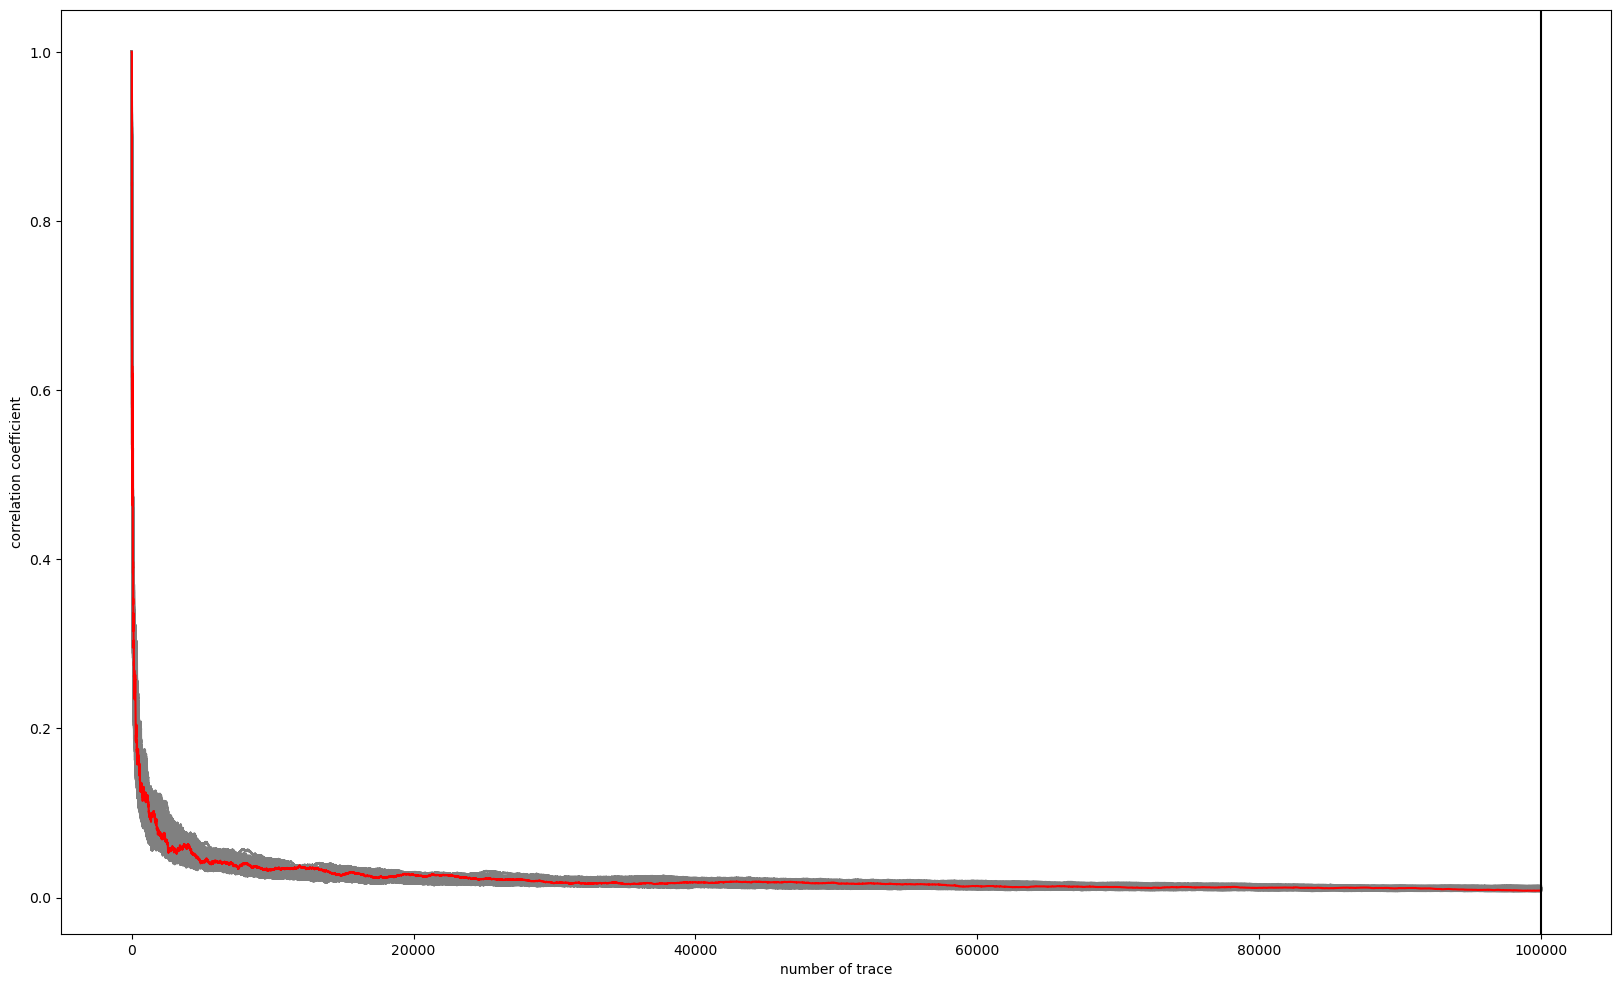

In [19]:
def plot_correlations(correlations: dict, m_key, rank_change_moment):
    plt.figure(figsize=(20, 12))
    for m_guess, cor in correlations.items():
        plt.plot(cor, color="gray")
    plt.plot(correlations[f"{m_key}"], color="red")

    plt.axvline(x=rank_change_moment, color="black")

    plt.xlabel("number of trace")
    plt.ylabel("correlation coefficient")

    plt.show()
    
plot_correlations(merged_correlations, m_key, rank_change_moment)